In [1]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

import numpy as np
from tslearn.clustering import TimeSeriesKMeans
from tslearn.datasets import CachedDatasets
from tslearn.preprocessing import TimeSeriesScalerMeanVariance, \
    TimeSeriesResampler
import seaborn as sns
from tslearn.utils import to_time_series_dataset
from tslearn.clustering import silhouette_score

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score 
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import sklearn.cluster

import os
from yellowbrick.cluster import SilhouetteVisualizer

import math
import scipy

from sklearn.metrics import adjusted_rand_score

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from tslearn.metrics import soft_dtw

In [2]:
def ts_cluster_visualization(y_pred, df, n_clusters, plot_title):
    ts_size = df.shape[1]
    ts_max = df.max()
    plt.figure()
    for cluster in range(n_clusters):
        plt.subplot(4, math.ceil(n_clusters/4), cluster+1)
        for ts in df[y_pred == cluster]:
            plt.plot(ts.ravel(), "k-", alpha=.2)
        plt.plot(np.mean(df[y_pred == cluster], axis=0), "r-")
        plt.xlim(0, ts_size)
        plt.ylim(0, ts_max)
        plt.text(0.55, 0.35,'Cluster %d' % (cluster),
                 transform=plt.gca().transAxes)
        if cluster == 1:
            plt.title(plot_title)      
    plt.tight_layout()
    plt.show()

In [4]:
def import_ff_data(filename):
    expected_columns=155
    data = []
    with open(filename, 'r') as file:
        for line in file:
            row = line.strip().split(',')
            if len(row) < expected_columns:
                row += [np.nan] * (expected_columns - len(row))
            data.append(row)
    df = pd.DataFrame(data)
    def fill_last_valid(row):
        for i in range(1, len(row)):
            if pd.isna(row[i]):
                row[i] = row[i - 1]  
        return row
    df_filled = df.apply(fill_last_valid, axis=1)
    return df_filled

# K means only plot

## Get no-embedding baselines

In [49]:
poor = pd.read_csv("SimData/bank_reserves_outputs_poor.csv", header=None)
middle = pd.read_csv("SimData/bank_reserves_outputs_middle.csv", header=None)
rich = pd.read_csv("SimData/bank_reserves_outputs_rich.csv", header=None)

br_combined = pd.concat([poor, middle, rich], axis=1)
br_combined = StandardScaler().fit_transform(br_combined)

k = 7   
kmeans = KMeans(n_clusters=k, random_state=42)
br_baseline_labels = kmeans.fit_predict(br_combined)

In [50]:
#distance_br_no_embedding_kmeans = ts_cluster_distance_silhouette(br_baseline_labels, poor.to_numpy(), middle.to_numpy(), rich.to_numpy(), 7)
import sklearn.metrics as m; 
br_none_kmeans = m.silhouette_score(br_combined, br_baseline_labels, metric='euclidean')

In [51]:
ecv_active = pd.read_csv("SimData/epsteinCV_outputs_active.csv", header=None)
ecv_jailed = pd.read_csv("SimData/epsteinCV_outputs_jailed.csv", header=None)
ecv_quiet = pd.read_csv("SimData/epsteinCV_outputs_quiet.csv", header=None)

ecv_combined = pd.concat([ecv_active, ecv_jailed, ecv_quiet], axis=1)
ecv_combined = StandardScaler().fit_transform(ecv_combined)

k = 8   
kmeans = KMeans(n_clusters=k, random_state=42)
ecv_baseline_labels = kmeans.fit_predict(ecv_combined)

In [52]:
ecv_none_kmeans = m.silhouette_score(ecv_combined, ecv_baseline_labels, metric='euclidean')

In [53]:
ff_onfire = import_ff_data("SimData/forest_fire_outputs_onfire.csv")
ff_fine = import_ff_data("SimData/forest_fire_outputs_fine.csv")
ff_burned = import_ff_data("SimData/forest_fire_outputs_burned.csv")

ff_combined = pd.concat([ff_onfire, ff_fine, ff_burned], axis=1)
ff_combined = StandardScaler().fit_transform(ff_combined)

k = 4   
kmeans = KMeans(n_clusters=k, random_state=42)
ff_baseline_labels = kmeans.fit_predict(ff_combined)

In [54]:
ff_none_kmeans = m.silhouette_score(ff_combined, ff_baseline_labels, metric='euclidean')

## PCA

In [55]:
label_results = pd.read_csv('bank_reserves_results.csv', index_col=0)
br_pca_kmeans = m.silhouette_score(br_combined, label_results.loc["PCA_KMeans"].to_numpy(), metric='euclidean')

In [56]:
label_results = pd.read_csv('epstein_results.csv', index_col=0)
ecv_pca_kmeans = m.silhouette_score(ecv_combined, label_results.loc["PCA_KMeans"].to_numpy(), metric='euclidean')

In [57]:
label_results = pd.read_csv('forestfire_results.csv', index_col=0)
ff_pca_kmeans = m.silhouette_score(ff_combined, label_results.loc["PCA_KMeans"].to_numpy(), metric='euclidean')

## DAE

In [58]:
label_results = pd.read_csv('bank_reserves_results.csv', index_col=0)
br_dae_kmeans = m.silhouette_score(br_combined, label_results.loc["DAE_KMeans"].to_numpy(), metric='euclidean')

In [59]:
label_results = pd.read_csv('epstein_results.csv', index_col=0)
ecv_dae_kmeans = m.silhouette_score(ecv_combined, label_results.loc["DAE_KMeans"].to_numpy(), metric='euclidean')

In [60]:
label_results = pd.read_csv('forestfire_results.csv', index_col=0)
ff_dae_kmeans = m.silhouette_score(ff_combined, label_results.loc["DAE_KMeans"].to_numpy(), metric='euclidean')

## DCAE

In [61]:
label_results = pd.read_csv('bank_reserves_results.csv', index_col=0)
br_dcae_kmeans = m.silhouette_score(br_combined, label_results.loc["DCAE_KMeans"].to_numpy(), metric='euclidean')

In [62]:
label_results = pd.read_csv('epstein_results.csv', index_col=0)
ecv_dcae_kmeans = m.silhouette_score(ecv_combined, label_results.loc["DCAE_KMeans"].to_numpy(), metric='euclidean')

In [63]:
label_results = pd.read_csv('forestfire_results.csv', index_col=0)
ff_dcae_kmeans = m.silhouette_score(ff_combined, label_results.loc["DCAE_KMeans"].to_numpy(), metric='euclidean')

## Format

In [64]:
models = ['Bank Reserves', 'Bank Reserves', 'Bank Reserves', 'Bank Reserves', 
                                    'Epstein', 'Epstein', 'Epstein', 'Epstein', 
                                    'Forest Fire', 'Forest Fire', 'Forest Fire', 'Forest Fire']

In [65]:
len(models)

12

In [66]:
fe = ['None', 'PCA', 'DCAE', 'DAE', 
      'None', 'PCA', 'DCAE', 'DAE', 
      'None', 'PCA', 'DCAE', 'DAE', 
      'None', 'PCA', 'DCAE', 'DAE']

In [67]:
len(fe)

16

In [68]:
df_kmeans = pd.DataFrame({'Model': ['Bank Reserves', 'Bank Reserves', 'Bank Reserves', 'Bank Reserves', 
                                    'Epstein', 'Epstein', 'Epstein', 'Epstein', 
                                    'Forest Fire', 'Forest Fire', 'Forest Fire', 'Forest Fire'], 
                        'Feature Embedding': ['None', 'PCA', 'DCAE', 'DAE', 
                                              'None', 'PCA', 'DCAE', 'DAE', 
                                              'None', 'PCA', 'DCAE', 'DAE'], 
                        'Silhouette Score': [br_none_kmeans, br_pca_kmeans, br_dae_kmeans, br_dcae_kmeans,
                                            ecv_none_kmeans, ecv_pca_kmeans, ecv_dae_kmeans, ecv_dcae_kmeans,
                                            ff_none_kmeans, ff_pca_kmeans, ff_dae_kmeans, ff_dcae_kmeans]
                         })

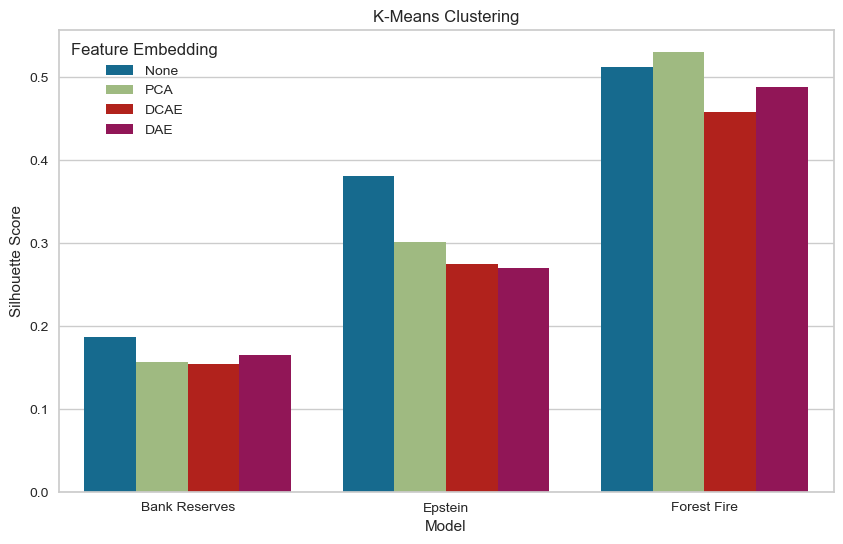

In [69]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_kmeans, x="Model", y="Silhouette Score", hue="Feature Embedding")

# Customize the plot
plt.xlabel("Model")
plt.ylabel("Silhouette Score")
plt.title("K-Means Clustering")
plt.legend(title="Feature Embedding")
#plt.ylim(10000, 20000)
plt.savefig("kmeans_embedding_comp.png", format="png")
plt.show()

# DAE only plot

In [70]:
label_results = pd.read_csv('bank_reserves_results.csv', index_col=0)
br_dae_kmeans = m.silhouette_score(br_combined, label_results.loc["DAE_KMeans"].to_numpy(), metric='euclidean')
br_dae_agglom = m.silhouette_score(br_combined, label_results.loc["DAE_Agglom"].to_numpy(), metric='euclidean')
br_dae_spectral = m.silhouette_score(br_combined, label_results.loc["DAE_Spectral"].to_numpy(), metric='euclidean')

In [71]:
label_results = pd.read_csv('epstein_results.csv', index_col=0)
ecv_dae_kmeans = m.silhouette_score(ecv_combined, label_results.loc["DAE_KMeans"].to_numpy(), metric='euclidean')
ecv_dae_agglom = m.silhouette_score(ecv_combined, label_results.loc["DAE_Agglom"].to_numpy(), metric='euclidean')
ecv_dae_spectral = m.silhouette_score(ecv_combined, label_results.loc["DAE_Spectral"].to_numpy(), metric='euclidean')

In [72]:
label_results = pd.read_csv('forestfire_results.csv', index_col=0)
ff_dae_kmeans = m.silhouette_score(ff_combined, label_results.loc["DAE_KMeans"].to_numpy(), metric='euclidean')
ff_dae_agglom = m.silhouette_score(ff_combined, label_results.loc["DAE_Agglom"].to_numpy(), metric='euclidean')
ff_dae_spectral = m.silhouette_score(ff_combined, label_results.loc["DAE_Spectral"].to_numpy(), metric='euclidean')

In [73]:
df_kmeans = pd.DataFrame({'Model': ['Bank Reserves', 'Bank Reserves', 'Bank Reserves', 
                                    'Epstein', 'Epstein', 'Epstein', 
                                    'Forest Fire', 'Forest Fire', 'Forest Fire'], 
                        'Clustering': ['K-Means', 'Agglom', 'Spectral', 
                                              'K-Means', 'Agglom', 'Spectral', 
                                              'K-Means', 'Agglom', 'Spectral'], 
                        'Silhouette Score': [br_dae_kmeans, br_dae_agglom, br_dae_spectral, 
                                            ecv_dae_kmeans, ecv_dae_agglom, ecv_dae_spectral, 
                                            ff_dae_kmeans, ff_dae_agglom, ff_dae_spectral]
                         })

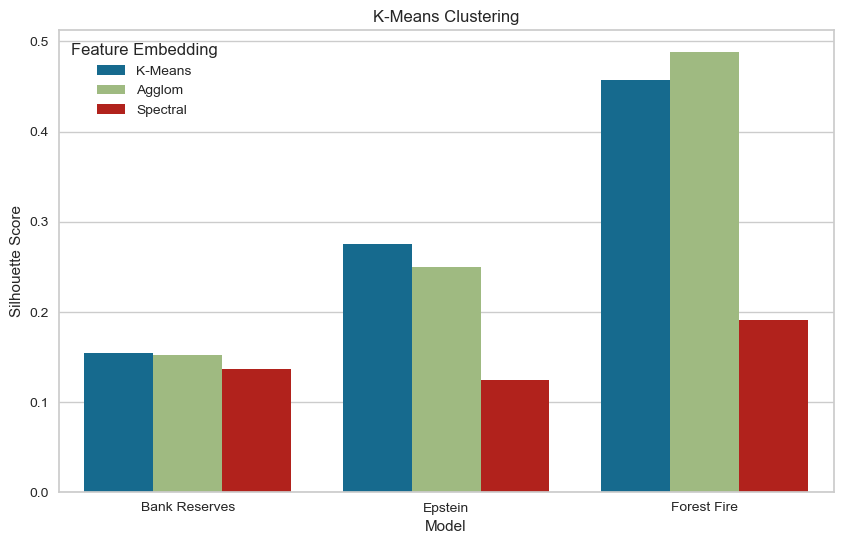

In [74]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_kmeans, x="Model", y="Silhouette Score", hue="Clustering")

# Customize the plot
plt.xlabel("Model")
plt.ylabel("Silhouette Score")
plt.title("K-Means Clustering")
plt.legend(title="Feature Embedding")
#plt.ylim(10000, 20000)
plt.savefig("dae_embedding_comp.png", format="png")
plt.show()